# Factor Analysis (FA) — scJDO Drift-Field Analysis | Bone Marrow Hematopoiesis

Uses Factor Analysis as the latent space for scJDO branch-separated drift fields.
Palantir provides branch-aware pseudotime; the FA latent geometry drives instability detection.

| Step | Tool | What it does |
|------|------|--------------|
| 1 | Palantir | Branch-aware pseudotime + branch masks (PCA diffusion manifold) |
| 2 | **FA** | **20-D latent space for scJDO drift field** |
| 3 | scJDO | Branch-separated drift fields: Ery · DC · Mono |
| 4 | scJDO | Instability genes + regulator networks per lineage |
| 5 | Robustness | Seed / cell / gene subsampling stability |
| 6 | Figure | 6-panel analysis figure |

**Dataset:** `marrow_sample_scseq_counts.h5ad` — 4,142 cells · 16,106 genes  
**Lineages:** Erythroid (Ery) · Dendritic Cell (DC) · Monocyte (Mono)

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import scanpy as sc
import palantir
import scjdo as sjd
from sklearn.decomposition import FactorAnalysis

OUTDIR = 'results/fa_analysis/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Fixed Palantir reference ──────────────────────────────────────────────
START_CELL = 'Run5_164698952452459'
TERMINAL_STATES = pd.Series(
    ['DC',                       'Mono',                      'Ery'],
    index=['Run5_131097901611291','Run5_134936662236454','Run4_200562869397916']
)
N_WAYPOINTS  = 500
PROGENITOR_Q = 0.75

# ── Analysis config ───────────────────────────────────────────────────────
N_LATENT      = 20
N_HVG         = 1500
TOP_N         = 30
BRANCHES      = ['Ery', 'DC', 'Mono']
BRANCH_COLORS = {'Ery': '#E63946', 'DC': '#2A9D8F', 'Mono': '#457B9D'}
ARCH_COLORS   = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#8338EC']

# ── Drift-field settings ──────────────────────────────────────────────────
N_EPOCHS      = 2000
N_ARCHETYPES  = 5
BIAS_STRENGTH = 1.5
VEL_SCALE     = 2.0
BASE_SEED     = 42

# ── Robustness ────────────────────────────────────────────────────────────
ROBUST_SEEDS     = [42, 123, 456, 789, 1234]
SUBSAMPLE_FRAC   = 0.80
N_GENE_SUBSAMPLE = 1200
N_SUBSAMPLE_RUNS = 3
RNG = np.random.default_rng(0)

# ── Canonical marker panels ───────────────────────────────────────────────
MARKERS = {
    'Ery':  ['GATA1', 'KLF1', 'BLVRB', 'ALAS2', 'ERMAP', 'HBB'],
    'DC':   ['IRF8', 'ZBTB46', 'FLT3', 'ITGAX', 'CLEC10A', 'BATF3'],
    'Mono': ['MPO', 'CTSG', 'ELANE', 'AZU1', 'LYZ', 'S100A8', 'SPI1'],
}

print(f'scjdo  v{sjd.__version__}')
print(f'palantir v{palantir.__version__}')
print(f'N_LATENT={N_LATENT}  N_HVG={N_HVG}  N_EPOCHS={N_EPOCHS}')
print(f'Drift: bias={BIAS_STRENGTH}, archetypes={N_ARCHETYPES}, vel_scale={VEL_SCALE}')
print(f'Branches: {BRANCHES}')

scjdo  v0.3.0
palantir v1.4.4
N_LATENT=20  N_HVG=1500  N_EPOCHS=2000
Drift: bias=1.5, archetypes=5, vel_scale=2.0
Branches: ['Ery', 'DC', 'Mono']


In [2]:
ad = sc.read('../examples/marrow_sample_scseq_counts.h5ad')
print(f'Loaded: {ad.n_obs} cells x {ad.n_vars} genes')

ad.layers['raw_counts'] = ad.X.copy()
sc.pp.normalize_per_cell(ad)
palantir.preprocess.log_transform(ad)

# ── HVG selection — fixed gene space for FA ───────────────────────────────
sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')
ad_hvg  = ad[:, ad.var.highly_variable].copy()
X_hvg   = ad_hvg.X.toarray() if hasattr(ad_hvg.X, 'toarray') else np.array(ad_hvg.X)
HVG_NAMES = ad_hvg.var_names.tolist()
print(f'HVGs: {len(HVG_NAMES)}  X_hvg: {X_hvg.shape}')

# ── Full-gene PCA + DiffMaps for Palantir ─────────────────────────────────
sc.pp.pca(ad, n_comps=50)
palantir.utils.run_diffusion_maps(ad, n_components=15)
palantir.utils.determine_multiscale_space(ad)
palantir.utils.run_magic_imputation(ad)
print('Full PCA + DiffMaps ready for Palantir')

Loaded: 4142 cells x 16106 genes
HVGs: 1500  X_hvg: (4142, 1500)
Full PCA + DiffMaps ready for Palantir


In [3]:
pr_res = palantir.core.run_palantir(
    ad, START_CELL,
    num_waypoints=N_WAYPOINTS,
    terminal_states=TERMINAL_STATES,
)

palantir.presults.select_branch_cells(
    ad, q=0.01, eps=0.01, masks_key='branch_masks', save_as_df=True
)

fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)
entropy_thr = ad.obs['palantir_entropy'].quantile(PROGENITOR_Q)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_thr, 'cell_fate'] = 'Progenitor'

SHARED_PT           = ad.obs['palantir_pseudotime'].copy()
SHARED_ENTROPY      = ad.obs['palantir_entropy'].copy()
SHARED_FATE         = ad.obs['cell_fate'].copy()
SHARED_MASKS        = ad.obsm['branch_masks'].copy()
SHARED_BRANCH_NAMES = list(ad.obsm['branch_masks'].columns)

# ── Fixed setup report ────────────────────────────────────────────────────
fate_vc = ad.obs['cell_fate'].value_counts()
terminal_pure = {b: int((fate_probs[b] >= fate_probs[b].quantile(0.98)).sum())
                 for b in BRANCHES}

print('=' * 60)
print('FIXED COMPARISON SETUP')
print('=' * 60)
rows_setup = [
    ('Total cells',                  f'{ad.n_obs:,}'),
    *[(f'Branch cells: {b}',         f'{int(SHARED_MASKS[b].sum()):,}') for b in BRANCHES],
    ('Progenitor cells',             f'{fate_vc.get("Progenitor", 0):,}'),
    *[(f'Terminal-pure: {b}',        f'{terminal_pure[b]:,}')           for b in BRANCHES],
    ('HVG count',                    f'{N_HVG:,}'),
    ('Latent dimension',             str(N_LATENT)),
    ('Drift-field epochs',           f'{N_EPOCHS:,}'),
    ('Bias strength',                str(BIAS_STRENGTH)),
    ('N archetypes',                 str(N_ARCHETYPES)),
    ('Progenitor entropy quantile',  str(PROGENITOR_Q)),
]
for label, value in rows_setup:
    print(f'  {label:<35} {value:>15}')
print('=' * 60)
print(f'Pseudotime: [{SHARED_PT.min():.3f}, {SHARED_PT.max():.3f}]')
print(f'Branches: {SHARED_BRANCH_NAMES}')


Sampling and flocking waypoints...
Time for determining waypoints: 8.352994918823243e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.017350566387176514 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
FIXED COMPARISON SETUP
  Total cells                                   4,142
  Branch cells: Ery                             1,510
  Branch cells: DC                              1,846
  Branch cells: Mono                            2,191
  Progenitor cells                              1,036
  Terminal-pure: Ery                               83
  Terminal-pure: DC                                83
  Terminal-pure: Mono                              83
  HVG count                               

UMAP computed: (4142, 2)
Branch cell counts:
  Ery: 1510 cells (36%)
  DC: 1846 cells (45%)
  Mono: 2191 cells (53%)

Cell fate labels (used for velocity bias):
cell_fate
Mono          2883
Progenitor    1036
Ery            171
DC              52


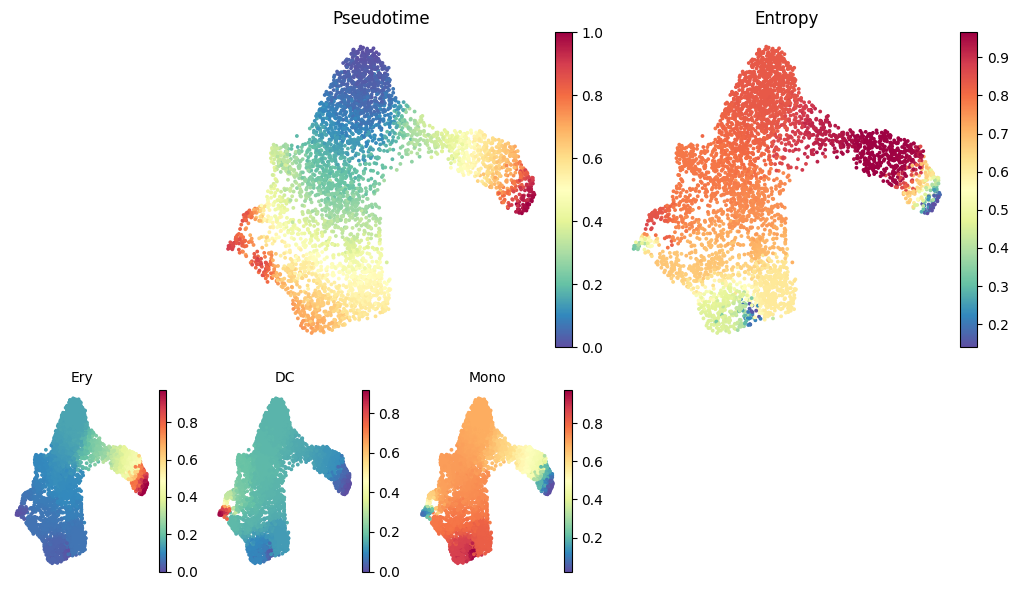

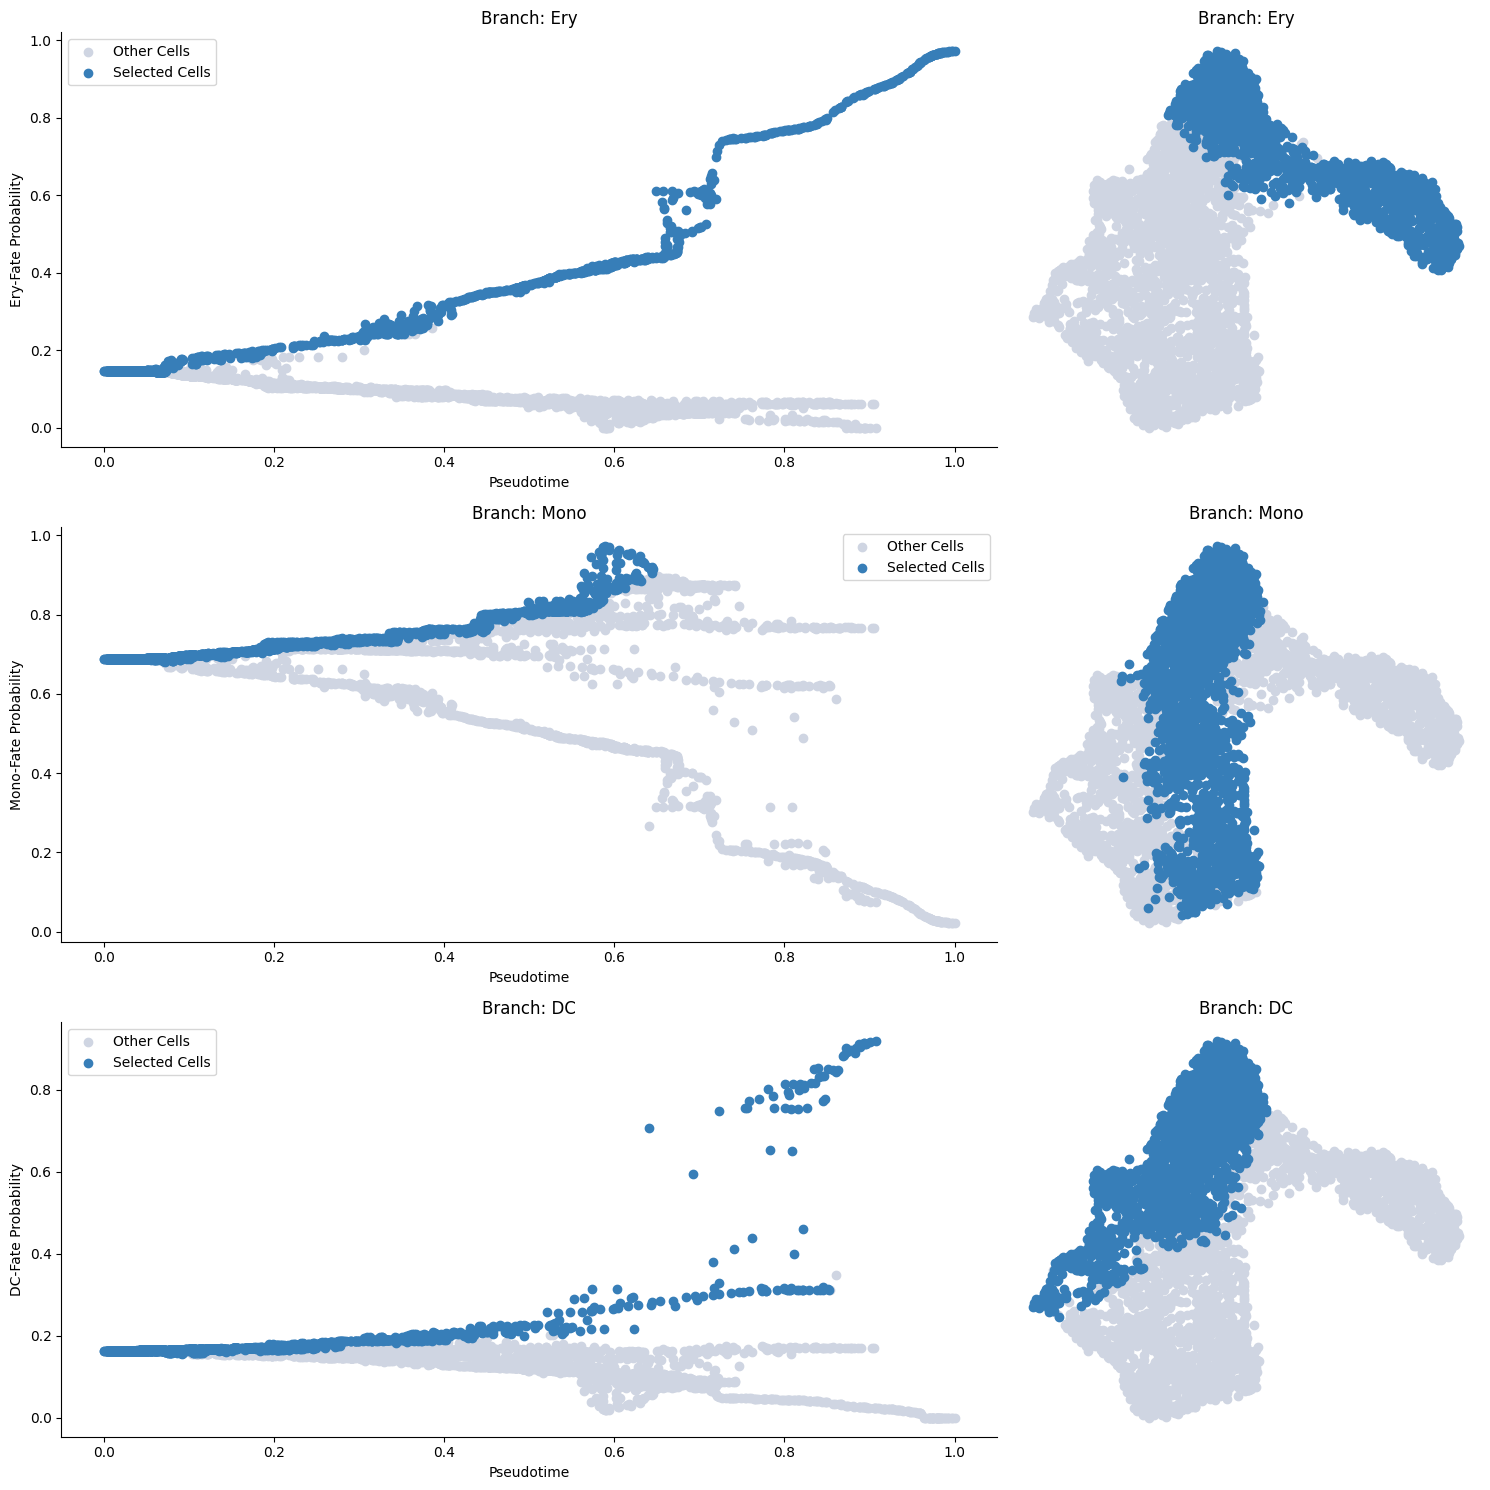

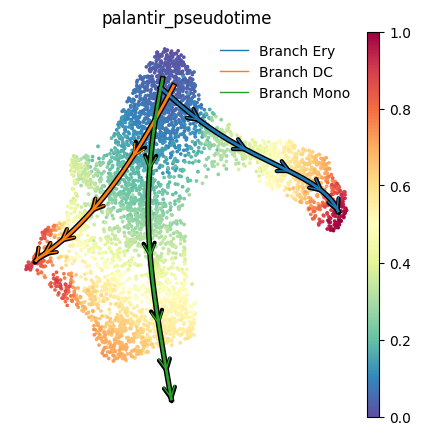

[2026-05-31 23:20:36,119] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,510) and rank = 1.0.
[2026-05-31 23:20:36,119] [INFO    ] Using covariance function Matern52(ls=1.2257417440414429).
[2026-05-31 23:20:36,120] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-31 23:20:36,131] [INFO    ] Sigma interpreted as element-wise standard deviation.


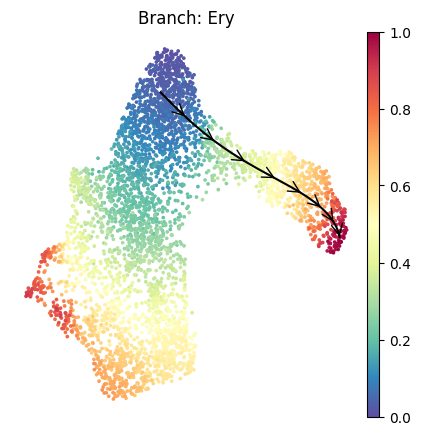

[2026-05-31 23:20:36,310] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,846) and rank = 1.0.
[2026-05-31 23:20:36,310] [INFO    ] Using covariance function Matern52(ls=1.2257417440414429).
[2026-05-31 23:20:36,311] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-31 23:20:36,324] [INFO    ] Sigma interpreted as element-wise standard deviation.


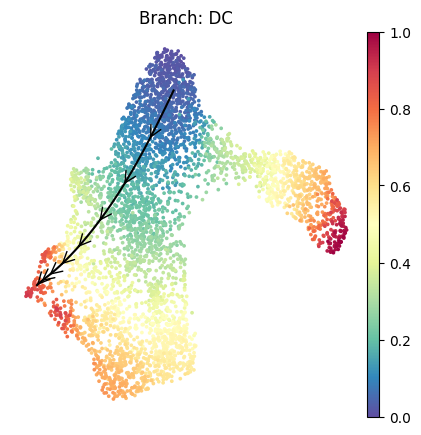

[2026-05-31 23:20:36,500] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,191) and rank = 1.0.
[2026-05-31 23:20:36,500] [INFO    ] Using covariance function Matern52(ls=1.2257417440414429).
[2026-05-31 23:20:36,501] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-31 23:20:36,513] [INFO    ] Sigma interpreted as element-wise standard deviation.


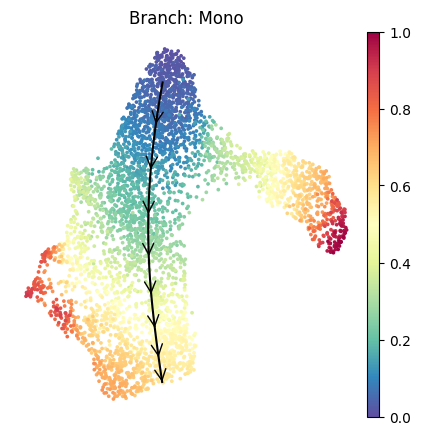

In [4]:
# ── UMAP on full-gene PCA (needed for palantir.plot functions) ────────────
if 'X_umap' not in ad.obsm:
    sc.pp.neighbors(ad, n_neighbors=30, n_pcs=15, use_rep='X_pca')
    sc.tl.umap(ad)
    print(f'UMAP computed: {ad.obsm["X_umap"].shape}')
else:
    print('UMAP already present.')

# ── select_branch_cells ───────────────────────────────────────────────────
palantir.presults.select_branch_cells(ad, q=0.01, eps=0.01,
                                       masks_key='branch_masks', save_as_df=True)
masks_df = ad.obsm['branch_masks']
print('Branch cell counts:')
for col in masks_df.columns:
    n = masks_df[col].sum()
    print(f'  {col}: {n} cells ({100*n/len(ad):.0f}%)')

# ── Create cell_fate label for biology-informed bias ──────────────────────
fate_probs = ad.obsm['palantir_fate_probabilities']
ad.obs['cell_fate'] = fate_probs.idxmax(axis=1).astype(str)

entropy_threshold = ad.obs['palantir_entropy'].quantile(0.75)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_threshold, 'cell_fate'] = 'Progenitor'

print('\nCell fate labels (used for velocity bias):')
print(ad.obs['cell_fate'].value_counts().to_string())

# ── Palantir visualizations ───────────────────────────────────────────────
palantir.plot.plot_palantir_results(ad, s=3)
plt.savefig(OUTDIR + 'palantir_results.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_branch_selection(ad)
plt.savefig(OUTDIR + 'branch_selection.pdf', dpi=150, bbox_inches='tight')
plt.show()

palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, 0.95))
plt.savefig(OUTDIR + 'trajectories.pdf', dpi=150, bbox_inches='tight')
plt.show()

for branch in ad.obsm['branch_masks'].columns:
    palantir.plot.plot_trajectory(ad, branch,
                                   cell_color='palantir_pseudotime', n_arrows=8)
    plt.savefig(OUTDIR + f'trajectory_{branch}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

In [5]:
# ── Factor Analysis — latent space for scJDO ────────────────────────────
model_fa = FactorAnalysis(n_components=N_LATENT, random_state=BASE_SEED)
W_fa     = model_fa.fit_transform(X_hvg).astype(np.float32)   # (n_cells, N_LATENT)
L_fa     = model_fa.components_.T.astype(np.float32)            # (n_hvg, N_LATENT)

print(f'FA embedding:  W_fa = {W_fa.shape}')
print(f'FA loadings:   L_fa = {L_fa.shape}')
print(f'Latent variance: {np.var(W_fa, axis=0).sum():.3f} (sum over {N_LATENT} factors)')

FA embedding:  W_fa = (4142, 20)
FA loadings:   L_fa = (1500, 20)
Latent variance: 16.816 (sum over 20 factors)



scJDO FA drift-field results:


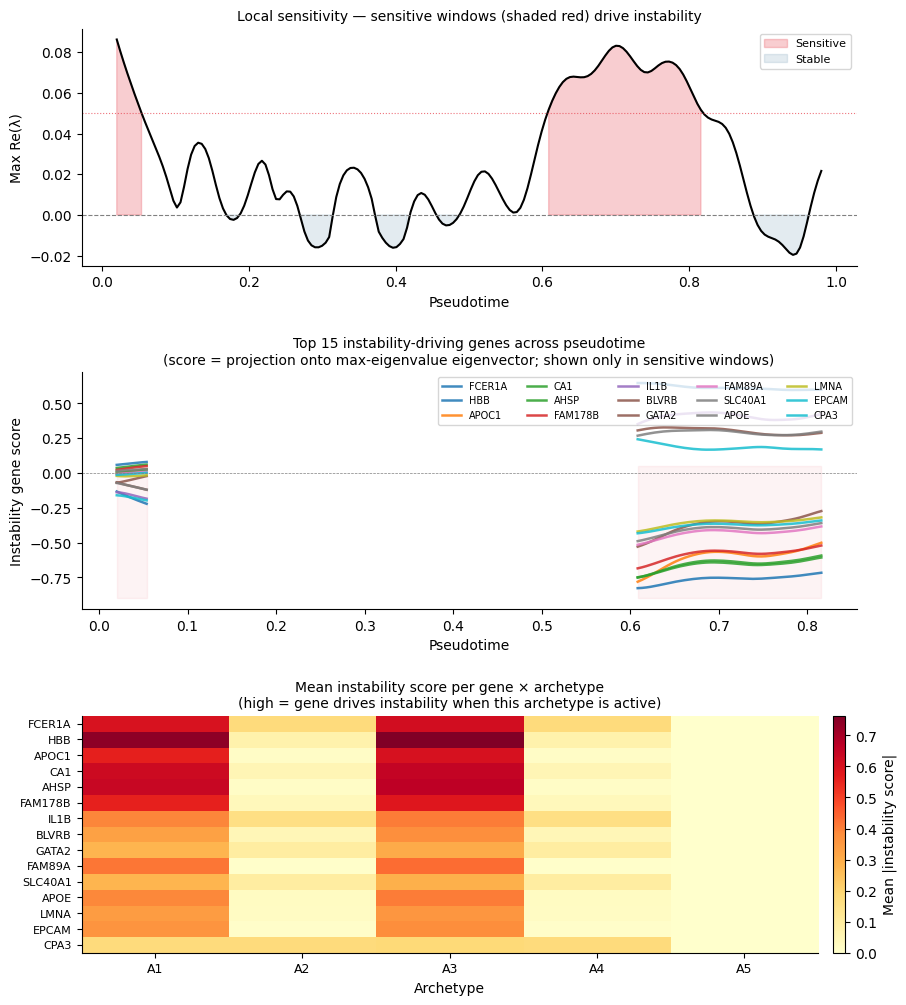

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1  FCER1A                  0.5321            0.613                A3
    2     HBB                  0.4894            0.609                A3
    3   APOC1                  0.4368            0.609                A3
    4     CA1                  0.4303            0.609                A3
    5    AHSP                  0.4245            0.609                A3
    6 FAM178B                  0.3796            0.609                A3
    7    IL1B                  0.3074            0.691                A3
    8   BLVRB                  0.3068            0.609                A3
    9   GATA2                  0.2941            0.642                A3
   10  FAM89A                  0.2918            0.609                A3
   11 SLC40A1                  0.2885            0.691                A3
   12    APOE                  0.2738            0.609                A3
   13    LMNA                  0.2405            0.

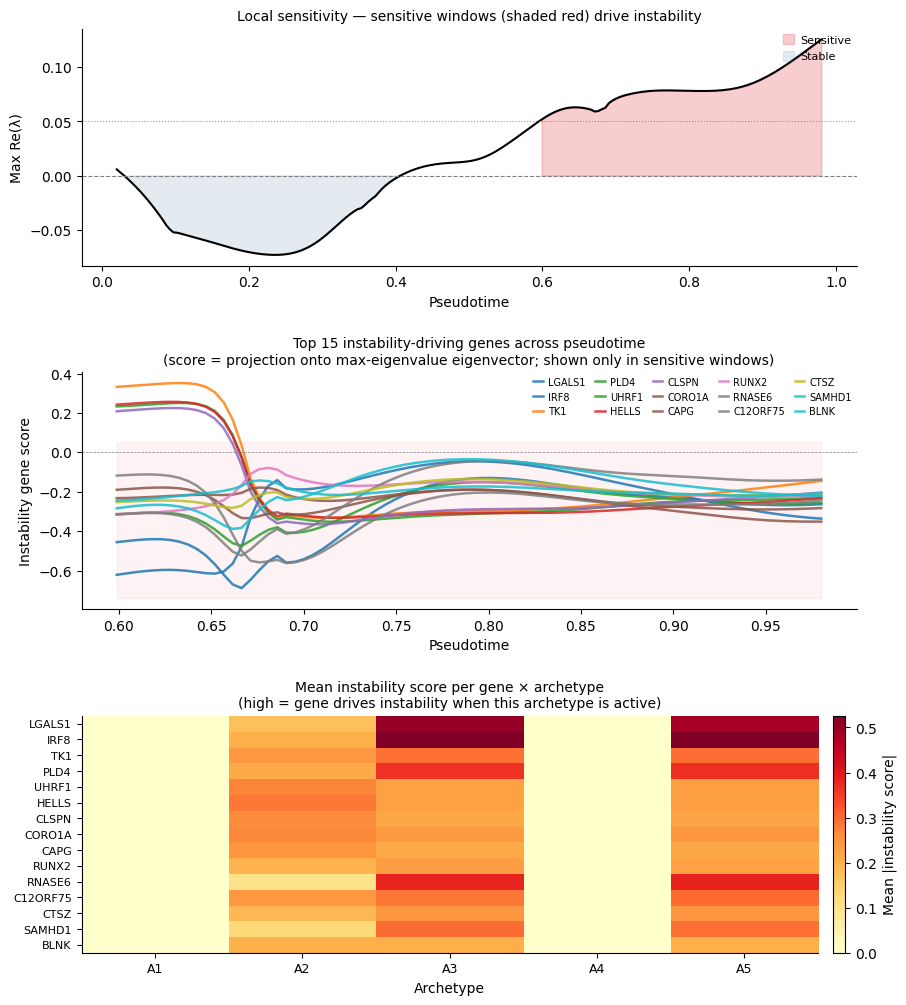

 rank     gene  mean_instability_score  peak_pseudotime primary_archetype
    1   LGALS1                  0.3636            0.599                A3
    2     IRF8                  0.3345            0.666                A3
    3      TK1                  0.2679            0.633                A3
    4     PLD4                  0.2606            0.666                A3
    5    UHRF1                  0.2512            0.715                A3
    6    HELLS                  0.2510            0.719                A3
    7    CLSPN                  0.2302            0.710                A3
    8   CORO1A                  0.2243            0.975                A2
    9     CAPG                  0.2229            0.951                A2
   10    RUNX2                  0.2224            0.599                A3
   11   RNASE6                  0.2133            0.666                A3
   12 C12ORF75                  0.2084            0.691                A3
   13     CTSZ                  0.2076

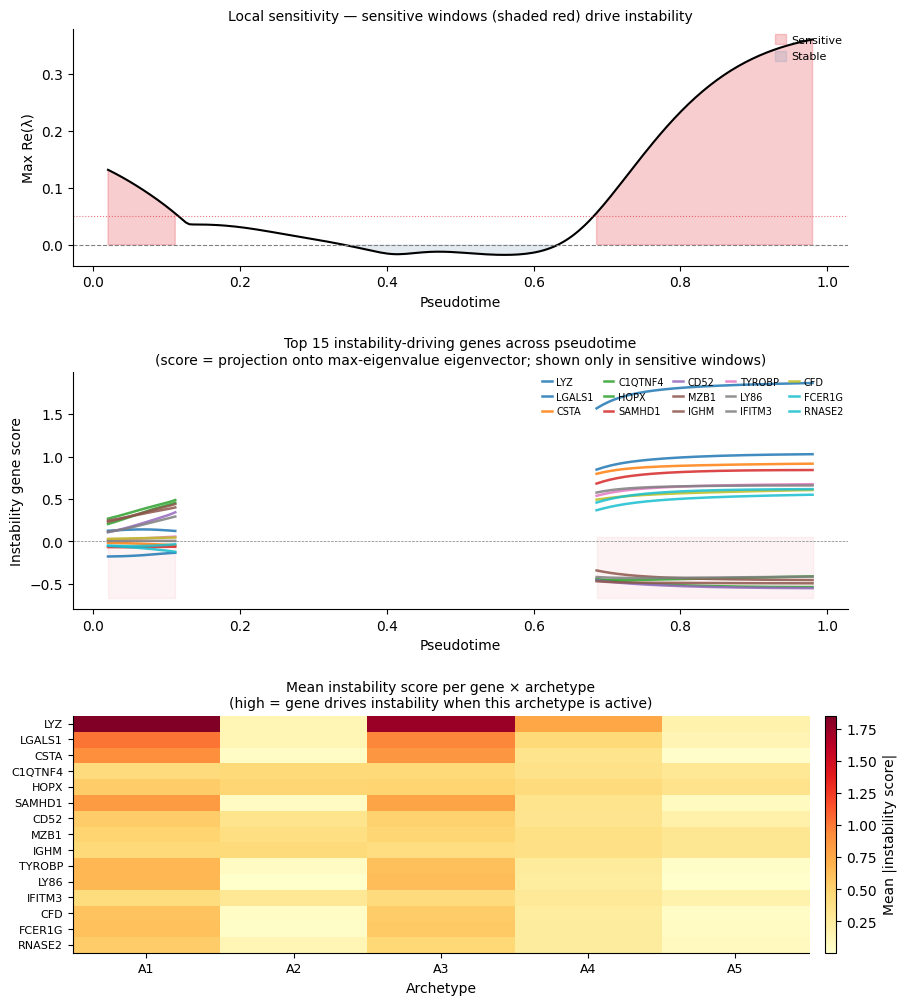

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1     LYZ                  0.9531            0.980                A1
    2  LGALS1                  0.5839            0.980                A1
    3    CSTA                  0.4811            0.980                A1
    4 C1QTNF4                  0.4575            0.112                A4
    5    HOPX                  0.4437            0.980                A1
    6  SAMHD1                  0.4337            0.980                A1
    7    CD52                  0.4230            0.980                A1
    8    MZB1                  0.4069            0.980                A1
    9    IGHM                  0.3911            0.980                A1
   10  TYROBP                  0.3583            0.980                A1
   11    LY86                  0.3320            0.980                A1
   12  IFITM3                  0.3236            0.744                A3
   13     CFD                  0.3122            0.

In [6]:
# ── Build adata for FA drift field ────────────────────────────────────────
ad_fa = ad_hvg.copy()
ad_fa.obs['palantir_pseudotime'] = SHARED_PT
ad_fa.obs['palantir_entropy']    = SHARED_ENTROPY
ad_fa.obs['cell_fate']           = SHARED_FATE
ad_fa.obsm['branch_masks']       = SHARED_MASKS
ad_fa.obsm['X_embed']            = W_fa
ad_fa.varm['PCs']                = L_fa
ad_fa.uns['scjdo_prep']        = {'latent': 'fa', 'rep': 'X_embed'}

# ── Fit branch-separated drift fields ─────────────────────────────────────
sjd.tl.fit_drift_branches(
    ad_fa,
    branch_key='branch_masks', branch_names=SHARED_BRANCH_NAMES,
    time_key='palantir_pseudotime', groupby='cell_fate',
    progenitor_cluster='Progenitor',
    terminal_clusters={b: b for b in BRANCHES},
    bias_strength=BIAS_STRENGTH, n_archetypes=N_ARCHETYPES,
    n_epochs=N_EPOCHS, rep='X_embed', vel_scale=VEL_SCALE,
    seed=BASE_SEED, verbose=False,
)

# ── Instability genes + regulators per branch ─────────────────────────────
FA_RESULTS = {}
FA_GENES   = {}
FA_REGS    = {}
_EMPTY_REGS = pd.DataFrame(columns=['regulator', 'weighted_score'])

print('\nscJDO FA drift-field results:')
for branch in BRANCHES:
    key = f'scjdo_{branch}'
    res = ad_fa.uns[key]
    FA_RESULTS[branch] = res

    cell_idx = np.array(res['branch_cells'])
    ad_b     = ad_fa[cell_idx].copy()
    ad_b.uns[key]    = res
    ad_b.varm['PCs'] = ad_fa.varm['PCs']
    ad_b.var_names   = ad_b.var_names.str.upper()

    table = sjd.pl.instability_genes(
        ad_b, key=key, n_genes=15,
        save=OUTDIR + f'instab_{branch}.pdf',
    )
    if 'gene' not in table.columns:
        eig_max = res['max_real_eig'].max()
        print(f'  [{branch}] No instability genes (max_eig={eig_max:.4f} < 0.05) — empty placeholder')
        table = pd.DataFrame(columns=['gene', 'mean_instability_score'])
    FA_GENES[branch] = table
    table.to_csv(OUTDIR + f'instab_genes_{branch}.csv', index=False)

    try:
        df_reg = sjd.tl.infer_regulators(
            ad_b, key=key, organism='human',
            n_top=15, min_targets=2,
            key_added=f'scjdo_regulators_{branch}', verbose=False,
        )
    except Exception as e:
        print(f'  [{branch}] infer_regulators: {e}')
        df_reg = _EMPTY_REGS.copy()
    FA_REGS[branch] = df_reg
    df_reg.to_csv(OUTDIR + f'regulators_{branch}.csv', index=False)

    eig      = res['max_real_eig']
    pi       = np.argmax(eig)
    top_genes = FA_GENES[branch]['gene'].head(5).tolist() if len(FA_GENES[branch]) else ['(none)']
    top_regs  = df_reg['regulator'].head(5).tolist() if len(df_reg) else ['(none)']
    print(f"\n{branch}:")
    print(f"  R²={res['r2']:.3f}, n_cells={res['n_cells']}, "
          f"peak_t={res['t_centers'][pi]:.3f}, max_eig={eig.max():.4f}, "
          f"n_sensitive={(eig > 0.05).sum()}/{len(eig)}")
    print(f"  Top genes: {top_genes}")
    print(f"  Top TFs:   {top_regs}")

In [7]:
print(f'Marker recovery — top-{TOP_N} instability genes (FA):\n')
BIO = {}
for branch in BRANCHES:
    genes   = [g.upper() for g in FA_RESULTS[branch].get('top_instability_genes', [])[:TOP_N]]
    markers = [m.upper() for m in MARKERS[branch]]
    hits    = sorted(set(genes) & set(markers))
    frac    = len(hits) / len(markers) if markers else 0.0
    BIO[branch] = {'frac': frac, 'hits': hits, 'n_markers': len(markers)}
    print(f'{branch}: {len(hits)}/{len(markers)} ({100*frac:.0f}%)  {hits}')

Marker recovery — top-30 instability genes (FA):

Ery: 3/6 (50%)  ['BLVRB', 'HBB', 'KLF1']
DC: 1/6 (17%)  ['IRF8']
Mono: 3/7 (43%)  ['LYZ', 'MPO', 'S100A8']


In [8]:
def jaccard(s1, s2):
    u = len(s1 | s2)
    return len(s1 & s2) / u if u > 0 else 0.0

GENE_SETS = {
    b: set(g.upper() for g in FA_RESULTS[b].get('top_instability_genes', [])[:TOP_N])
    for b in BRANCHES
}
EXCL = {
    b: GENE_SETS[b] - set().union(*[GENE_SETS[ob] for ob in BRANCHES if ob != b])
    for b in BRANCHES
}
SHARED_ALL = set.intersection(*GENE_SETS.values()) if all(GENE_SETS.values()) else set()

pairs_j = {}
for i, b1 in enumerate(BRANCHES):
    for b2 in BRANCHES[i+1:]:
        pairs_j[f'{b1}/{b2}'] = jaccard(GENE_SETS[b1], GENE_SETS[b2])

mean_j = float(np.mean(list(pairs_j.values()))) if pairs_j else 0.0
print(f'Branch specificity — FA (top-{TOP_N} instability genes):')
print(f'  Mean Jaccard: {mean_j:.3f}  →  Specificity: {1-mean_j:.3f}')
for k, v in pairs_j.items():
    print(f'  Jaccard {k}: {v:.3f}')
print(f'  Shared all 3: {len(SHARED_ALL)}  {sorted(SHARED_ALL)}')
print()
for b in BRANCHES:
    print(f'  {b}: {len(GENE_SETS[b])} total, {len(EXCL[b])} exclusive')
    print(f'    Top exclusive: {sorted(EXCL[b])[:10]}')

Branch specificity — FA (top-30 instability genes):
  Mean Jaccard: 0.084  →  Specificity: 0.916
  Jaccard Ery/DC: 0.000
  Jaccard Ery/Mono: 0.053
  Jaccard DC/Mono: 0.200
  Shared all 3: 0  []

  Ery: 30 total, 27 exclusive
    Top exclusive: ['AHSP', 'ANK1', 'APOC1', 'APOE', 'BLVRB', 'CA1', 'CAST', 'CD36', 'EPCAM', 'EREG']
  DC: 30 total, 20 exclusive
    Top exclusive: ['ALOX5AP', 'BLNK', 'C12ORF75', 'CAPG', 'CCDC50', 'CLSPN', 'CTSZ', 'HELLS', 'HLA-DMB', 'IGKC']
  Mono: 30 total, 17 exclusive
    Top exclusive: ['ANXA2', 'CD69', 'CEBPD', 'CFD', 'CSTA', 'FAM107B', 'IFITM3', 'IGHM', 'IGSF6', 'LY86']


In [1]:
def _peak_t(res):
    if res is None: return float('nan')
    return float(res['t_centers'][np.argmax(res['max_real_eig'])])


def fa_drift(obs_idx=None, var_idx=None, seed=BASE_SEED, progenitor_q=PROGENITOR_Q):
    """Run FA + drift field on an optionally subsampled dataset."""
    if obs_idx is None:
        obs_idx = np.arange(len(ad_hvg))
    X_sub = X_hvg[obs_idx]
    X_fit = X_sub[:, var_idx] if var_idx is not None else X_sub

    n_comp = min(N_LATENT, X_fit.shape[0] - 1, X_fit.shape[1] - 1)
    model  = FactorAnalysis(n_components=n_comp, random_state=seed)
    W      = model.fit_transform(X_fit).astype(np.float32)
    L      = np.zeros((N_HVG, n_comp), dtype=np.float32)
    L[var_idx if var_idx is not None else np.arange(N_HVG)] = model.components_.T.astype(np.float32)

    _ad = ad_hvg[obs_idx].copy()
    _ad.obs['palantir_pseudotime'] = SHARED_PT.values[obs_idx]
    _ad.obs['palantir_entropy']    = SHARED_ENTROPY.values[obs_idx]

    fp     = ad.obsm['palantir_fate_probabilities']
    fp_sub = fp.iloc[obs_idx] if hasattr(fp, 'iloc') else fp[obs_idx]
    fate   = fp_sub.idxmax(axis=1).astype(str)
    ent_sub = SHARED_ENTROPY.values[obs_idx]
    fate[ent_sub >= np.quantile(ent_sub, progenitor_q)] = 'Progenitor'
    _ad.obs['cell_fate'] = fate.values

    _ad.obsm['branch_masks'] = pd.DataFrame(
        SHARED_MASKS.values[obs_idx],
        columns=SHARED_MASKS.columns, index=_ad.obs_names,
    )
    _ad.obsm['X_embed']     = W
    _ad.varm['PCs']         = L
    _ad.uns['scjdo_prep'] = {'latent': 'fa', 'rep': 'X_embed'}

    try:
        sjd.tl.fit_drift_branches(
            _ad, branch_key='branch_masks', branch_names=SHARED_BRANCH_NAMES,
            time_key='palantir_pseudotime', groupby='cell_fate',
            progenitor_cluster='Progenitor',
            terminal_clusters={b: b for b in BRANCHES},
            bias_strength=BIAS_STRENGTH, n_archetypes=N_ARCHETYPES,
            n_epochs=N_EPOCHS, rep='X_embed', vel_scale=VEL_SCALE,
            seed=seed, verbose=False,
        )
        return {b: _ad.uns.get(f'scjdo_{b}') for b in BRANCHES}
    except Exception as e:
        print(f'  [warn] fa_drift failed: {e}')
        return {b: None for b in BRANCHES}


# ── Test 1: Random seeds ──────────────────────────────────────────────────
print(f'Test 1: Seed stability  (N={len(ROBUST_SEEDS)} seeds)')
SEED_RUNS = []
for seed in ROBUST_SEEDS:
    print(f'  seed={seed}...', end='', flush=True)
    br = fa_drift(seed=seed)
    SEED_RUNS.append(br)
    for b in BRANCHES:
        r = br.get(b)
        print(f'  {b}: t={_peak_t(r):.3f}, λ={r["max_real_eig"].max():.3f}' if r else f'  {b}: FAIL', end='')
    print()

SEED_STABILITY = {}
print('\nSeed stability (peak_t mean ± std):')
for b in BRANCHES:
    pts = [_peak_t(sr.get(b)) for sr in SEED_RUNS if sr.get(b) is not None]
    SEED_STABILITY[b] = (np.mean(pts), np.std(pts), pts)
    print(f'  {b}: {np.mean(pts):.3f} ± {np.std(pts):.4f}  (N={len(pts)})')

# ── Test 2: Cell subsampling ──────────────────────────────────────────────
print(f'\nTest 2: Cell subsampling  ({int(100*SUBSAMPLE_FRAC)}%, N={N_SUBSAMPLE_RUNS} runs)')
CELL_SUB_RUNS = []
for i in range(N_SUBSAMPLE_RUNS):
    idx = np.where(RNG.random(len(ad_hvg)) < SUBSAMPLE_FRAC)[0]
    print(f'  run {i+1}: {len(idx)} cells...', end='', flush=True)
    br = fa_drift(obs_idx=idx, seed=ROBUST_SEEDS[i])
    CELL_SUB_RUNS.append(br)
    for b in BRANCHES: print(f'  {b}: {_peak_t(br.get(b)):.3f}', end='')
    print()

# ── Test 3: Gene subsampling ──────────────────────────────────────────────
print(f'\nTest 3: Gene subsampling  ({N_GENE_SUBSAMPLE}/{N_HVG} HVGs, N={N_SUBSAMPLE_RUNS} runs)')
GENE_SUB_RUNS = []
for i in range(N_SUBSAMPLE_RUNS):
    g_idx = np.sort(RNG.choice(N_HVG, N_GENE_SUBSAMPLE, replace=False))
    print(f'  run {i+1}: {len(g_idx)} genes...', end='', flush=True)
    br = fa_drift(var_idx=g_idx, seed=ROBUST_SEEDS[i])
    GENE_SUB_RUNS.append(br)
    for b in BRANCHES: print(f'  {b}: {_peak_t(br.get(b)):.3f}', end='')
    print()

# ── Test 4: Perturbed progenitor quantile ─────────────────────────────────
print('\nTest 4: Progenitor entropy quantile  (0.70 / 0.75 / 0.80)')
PERT_Q_RUNS = {}
for q in [0.70, 0.75, 0.80]:
    n_prog = int((SHARED_ENTROPY >= SHARED_ENTROPY.quantile(q)).sum())
    print(f'  q={q:.2f} ({n_prog} progenitors)...', end='', flush=True)
    br = fa_drift(seed=BASE_SEED, progenitor_q=q)
    PERT_Q_RUNS[q] = br
    for b in BRANCHES: print(f'  {b}: {_peak_t(br.get(b)):.3f}', end='')
    print()

print('\nRobustness analysis complete.')

NameError: name 'BASE_SEED' is not defined

In [2]:
fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(3, 2, hspace=0.52, wspace=0.42,
                        left=0.10, right=0.97, top=0.93, bottom=0.05)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

# ── a: Sensitivity profiles ───────────────────────────────────────────────
for branch in BRANCHES:
    res    = FA_RESULTS[branch]
    t      = res['t_centers']
    eig    = res['max_real_eig']
    pi     = np.argmax(eig)
    ax_a.plot(t, eig, color=BRANCH_COLORS[branch], lw=2.2,
              label=f"{branch}  (n={res['n_cells']}, R²={res['r2']:.3f})")
    ax_a.fill_between(t, eig, 0, where=(eig >= 0.05), alpha=0.18, color=BRANCH_COLORS[branch])
    ax_a.axvline(t[pi], color=BRANCH_COLORS[branch], lw=1.0, ls=':', alpha=0.7)
    ax_a.annotate(f"t={t[pi]:.2f}", xy=(t[pi], eig[pi]),
                  xytext=(t[pi] + 0.04, eig[pi] * 0.85),
                  arrowprops=dict(arrowstyle='->', color=BRANCH_COLORS[branch], lw=1.0),
                  fontsize=7.5, color=BRANCH_COLORS[branch])
ax_a.axhline(0,    color='gray', lw=0.8, ls='--')
ax_a.axhline(0.05, color='gray', lw=0.6, ls=':', alpha=0.5)
ax_a.set_xlabel('Pseudotime')
ax_a.set_ylabel('Max Re(λ)')
ax_a.legend(fontsize=8, loc='upper left')
ax_a.set_title('a  |  FA sensitivity profiles — all lineages',
               fontweight='bold', loc='left', fontsize=11)

# ── b: Fit R² ─────────────────────────────────────────────────────────────
x_b     = np.arange(len(BRANCHES))
r2_vals = [FA_RESULTS[b]['r2'] for b in BRANCHES]
pt_vals = [FA_RESULTS[b]['t_centers'][np.argmax(FA_RESULTS[b]['max_real_eig'])] for b in BRANCHES]
ax_b.bar(x_b, r2_vals, color=[BRANCH_COLORS[b] for b in BRANCHES], alpha=0.85, width=0.6)
for xi, (r2v, ptv) in enumerate(zip(r2_vals, pt_vals)):
    ax_b.text(xi, r2v + 0.001, f'{r2v:.3f}', ha='center', va='bottom', fontsize=9)
    ax_b.text(xi, 0.02, f'peak={ptv:.2f}', ha='center', va='bottom',
               fontsize=7, color='white', fontweight='bold')
ax_b.set_xticks(x_b); ax_b.set_xticklabels(BRANCHES, fontsize=9)
ax_b.set_ylim(0, 1.07)
ax_b.set_ylabel('Fit R²')
ax_b.set_title('b  |  Drift-field fit quality', fontweight='bold', loc='left', fontsize=11)

# ── c: Top instability genes (all branches stacked) ───────────────────────
N_GENES     = 8
GAP         = 2
branch_order = ['Mono', 'DC', 'Ery']  # bottom → top

def _pad_genes(df, n):
    while len(df) < n:
        df = pd.concat(
            [df, pd.DataFrame({'gene': ['—'], 'mean_instability_score': [0.0]})],
            ignore_index=True,
        )
    return df.head(n)

offsets = {}
y_start = 0
for b in branch_order:
    offsets[b] = np.arange(y_start, y_start + N_GENES)
    y_start += N_GENES + GAP

x_max_c = max(
    (FA_GENES[b]['mean_instability_score'].max() if len(FA_GENES[b]) else 0)
    for b in branch_order
)
x_max_c = max(x_max_c, 0.01)

all_yticks, all_labels = [], []
for b in branch_order:
    df_b = _pad_genes(FA_GENES[b].head(N_GENES).reset_index(drop=True), N_GENES)
    ax_c.barh(offsets[b], df_b['mean_instability_score'],
              color=BRANCH_COLORS[b], alpha=0.85, height=0.75)
    for y, val in zip(offsets[b], df_b['mean_instability_score']):
        if val > 0:
            ax_c.text(val + x_max_c * 0.01, y, f'{val:.3f}',
                       va='center', ha='left', fontsize=6)
    mid = offsets[b].mean()
    ax_c.text(x_max_c * 1.02, mid, b, color=BRANCH_COLORS[b],
               fontsize=9, fontweight='bold', va='center', ha='left')
    all_yticks.extend(offsets[b])
    all_labels.extend(df_b['gene'].tolist())

ax_c.set_yticks(all_yticks)
ax_c.set_yticklabels(all_labels, fontsize=7.5)
ax_c.set_xlim(0, x_max_c * 1.25)
# Separator lines between branches
ax_c.axhline(offsets['DC'][0] - GAP / 2, color='gray', lw=0.8, ls='--', alpha=0.5)
ax_c.axhline(offsets['Ery'][0] - GAP / 2, color='gray', lw=0.8, ls='--', alpha=0.5)
ax_c.set_xlabel('Mean instability score')
ax_c.set_title('c  |  Top instability genes per lineage',
               fontweight='bold', loc='left', fontsize=11)

# ── d: Marker recovery ────────────────────────────────────────────────────
x_d   = np.arange(len(BRANCHES))
fracs = [BIO[b]['frac'] for b in BRANCHES]
ax_d.bar(x_d, [f * 100 for f in fracs],
         color=[BRANCH_COLORS[b] for b in BRANCHES], alpha=0.85, width=0.6)
for xi, (b, frac) in enumerate(zip(BRANCHES, fracs)):
    hits = BIO[b]['hits']
    n_m  = BIO[b]['n_markers']
    ax_d.text(xi, frac * 100 + 1.5, f'{len(hits)}/{n_m}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')
    if hits:
        ax_d.text(xi, max(frac * 100 - 12, 3), '\n'.join(hits[:3]),
                   ha='center', va='bottom', fontsize=6, color='white', fontweight='bold')
ax_d.set_xticks(x_d); ax_d.set_xticklabels(BRANCHES, fontsize=9)
ax_d.set_ylim(0, 110)
ax_d.axhline(50, color='gray', lw=0.8, ls=':', alpha=0.5)
ax_d.set_ylabel('Marker recovery (%)')
ax_d.set_title(f'd  |  Canonical marker recovery (top-{TOP_N})',
               fontweight='bold', loc='left', fontsize=11)

# ── e: Branch specificity (exclusive vs shared) ────────────────────────────
x_e  = np.arange(len(BRANCHES))
excl = [len(EXCL[b]) for b in BRANCHES]
shrd = [len(GENE_SETS[b]) - len(EXCL[b]) for b in BRANCHES]
tot  = [len(GENE_SETS[b]) for b in BRANCHES]
ax_e.bar(x_e, excl, color=[BRANCH_COLORS[b] for b in BRANCHES],
          alpha=0.85, width=0.6, label='Exclusive to lineage')
ax_e.bar(x_e, shrd, bottom=excl,
          color=[BRANCH_COLORS[b] for b in BRANCHES],
          alpha=0.35, width=0.6, hatch='//', label='Shared with ≥1 lineage')
for xi, (ex, to) in enumerate(zip(excl, tot)):
    ax_e.text(xi, to + 0.3, f'{ex}/{to}', ha='center', va='bottom', fontsize=8.5)
ax_e.set_xticks(x_e); ax_e.set_xticklabels(BRANCHES, fontsize=9)
ax_e.set_ylabel(f'Instability genes (top-{TOP_N})')
ax_e.legend(fontsize=8, loc='upper right')
ax_e.text(0.02, 0.97, f'Specificity = {1-mean_j:.3f}  (1 − mean Jaccard)',
           transform=ax_e.transAxes, fontsize=7.5, va='top',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='#ccc'))
ax_e.set_title('e  |  Branch specificity', fontweight='bold', loc='left', fontsize=11)

# ── f: FA seed stability ───────────────────────────────────────────────────
for bi, branch in enumerate(BRANCHES):
    mean_pt, std_pt, pts = SEED_STABILITY[branch]
    ax_f.scatter([bi]*len(pts), pts, color=BRANCH_COLORS[branch], alpha=0.6, s=55, zorder=3)
    ax_f.errorbar(bi, mean_pt, yerr=std_pt, color=BRANCH_COLORS[branch],
                   capsize=5, lw=2.5, fmt='D', markeredgecolor='black', zorder=4, ms=8)
ax_f.set_xticks(np.arange(len(BRANCHES))); ax_f.set_xticklabels(BRANCHES, fontsize=9)
ax_f.set_ylim(0, 1.05)
ax_f.axhline(0.5, color='gray', lw=0.7, ls=':', alpha=0.5)
ax_f.set_ylabel('Peak instability pseudotime')
ax_f.set_title(f'f  |  FA seed stability (N={len(ROBUST_SEEDS)} seeds)',
               fontweight='bold', loc='left', fontsize=11)

# ── Suptitle + save ────────────────────────────────────────────────────────
fig.suptitle(
    f'Factor Analysis (FA) — scJDO Drift-Field Analysis\n'
    f'Bone Marrow Hematopoiesis  '
    f'(N_LATENT={N_LATENT}, N_HVG={N_HVG}, Palantir pseudotime)',
    fontsize=12, fontweight='bold',
)
fig.savefig(OUTDIR + 'fa_analysis_figure.pdf', dpi=300, bbox_inches='tight')
fig.savefig(OUTDIR + 'fa_analysis_figure.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTDIR}fa_analysis_figure.pdf / .png')

NameError: name 'plt' is not defined

In [11]:
SEP = '=' * 90
print(SEP)
print(f'{"Branch":6s}  {"n_cells":>7}  {"R²":>6}  {"peak_t":>7}  {"max_λ":>8}  '
      f'{"n_sens":>6}  {"markers%":>9}  {"excl_genes":>10}  Top-5 genes')
print('-' * 90)
for branch in BRANCHES:
    res  = FA_RESULTS[branch]
    pi   = np.argmax(res['max_real_eig'])
    n_s  = int((res['max_real_eig'] > 0.05).sum())
    mr   = BIO[branch]['frac']
    ex   = len(EXCL[branch])
    top5 = ', '.join(res.get('top_instability_genes', [])[:5]) or '(none)'
    print(f"{branch:6s}  {res['n_cells']:>7}  {res['r2']:>6.3f}  "
          f"{res['t_centers'][pi]:>7.3f}  {res['max_real_eig'][pi]:>8.4f}  "
          f"{n_s:>6}  {100*mr:>8.0f}%  {ex:>10}  {top5}")

print('\n' + SEP)
print('Marker hits:')
for branch in BRANCHES:
    print(f"  {branch}: {BIO[branch]['hits']}")

print('\nFA Robustness:')
print(f'  Seed stability (N={len(ROBUST_SEEDS)} seeds):')
for b in BRANCHES:
    m, s, pts = SEED_STABILITY[b]
    print(f'    {b}: peak_t = {m:.3f} ± {s:.4f}')

print(f'\n  Cell subsampling ({int(100*SUBSAMPLE_FRAC)}%, N={N_SUBSAMPLE_RUNS}):')
for b in BRANCHES:
    pts = [_peak_t(r.get(b)) for r in CELL_SUB_RUNS if r.get(b) is not None]
    if pts: print(f'    {b}: {np.mean(pts):.3f} ± {np.std(pts):.4f}')

print(f'\n  Gene subsampling ({N_GENE_SUBSAMPLE}/{N_HVG} HVGs, N={N_SUBSAMPLE_RUNS}):')
for b in BRANCHES:
    pts = [_peak_t(r.get(b)) for r in GENE_SUB_RUNS if r.get(b) is not None]
    if pts: print(f'    {b}: {np.mean(pts):.3f} ± {np.std(pts):.4f}')

print('\n  Progenitor quantile perturbation (0.70 / 0.75 / 0.80):')
for q, br in PERT_Q_RUNS.items():
    vals = '   '.join(f'{b}: {_peak_t(br.get(b)):.3f}' for b in BRANCHES)
    print(f'    q={q:.2f}: {vals}')

import json
summary = {}
for branch in BRANCHES:
    res  = FA_RESULTS[branch]
    pi   = np.argmax(res['max_real_eig'])
    m, s, _ = SEED_STABILITY[branch]
    summary[branch] = {
        'n_cells':         res['n_cells'],
        'r2':              round(float(res['r2']), 3),
        'peak_t':          round(float(res['t_centers'][pi]), 3),
        'max_eig':         round(float(res['max_real_eig'][pi]), 4),
        'n_sensitive':     int((res['max_real_eig'] > 0.05).sum()),
        'marker_recovery': round(BIO[branch]['frac'], 3),
        'marker_hits':     BIO[branch]['hits'],
        'excl_genes':      len(EXCL[branch]),
        'specificity':     round(1 - mean_j, 3),
        'top_5_genes':     res.get('top_instability_genes', [])[:5],
        'top_5_tfs':       FA_REGS[branch]['regulator'].head(5).tolist() if len(FA_REGS[branch]) else [],
        'seed_stability':  {'mean': round(m, 3), 'std': round(s, 4)},
    }
with open(OUTDIR + 'fa_analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\nCSVs + JSON saved to: {OUTDIR}')

Branch  n_cells      R²   peak_t     max_λ  n_sens   markers%  excl_genes  Top-5 genes
------------------------------------------------------------------------------------------
Ery        1510   0.998    0.020    0.0862      52        50%          27  FCER1A, HBB, APOC1, CA1, AHSP
DC         1846   0.998    0.980    0.1258      80        17%          20  LGALS1, IRF8, TK1, PLD4, UHRF1
Mono       2191   1.000    0.980    0.3612      82        43%          17  LYZ, LGALS1, CSTA, C1QTNF4, HOPX

Marker hits:
  Ery: ['BLVRB', 'HBB', 'KLF1']
  DC: ['IRF8']
  Mono: ['LYZ', 'MPO', 'S100A8']

FA Robustness:
  Seed stability (N=5 seeds):
    Ery: peak_t = 0.117 ± 0.1334
    DC: peak_t = 0.980 ± 0.0000
    Mono: peak_t = 0.788 ± 0.3840

  Cell subsampling (80%, N=3):
    Ery: 0.367 ± 0.2260
    DC: 0.980 ± 0.0000
    Mono: 0.660 ± 0.4525

  Gene subsampling (1200/1500 HVGs, N=3):
    Ery: 0.284 ± 0.2949
    DC: 0.980 ± 0.0000
    Mono: 0.980 ± 0.0000

  Progenitor quantile perturbation (0.70 / 0